# Aqueduct river-flood hazard example

Aqueduct v2 provides a global dataset of river-flood inundation depth maps created by the World Resources Institute. The maps are organized by climate change scenario, past/future year, climate model, and return period.

This example uses the code from this repository to create an example Hazard object for just a couple of return periods for eastern Jamaica.

See the end of the notebook for a single function call that does everything together.

## Imports and environment setup

The module uses Python logging to report file reuse, downloads, and hazard creation. Enable logging here to see these steps. The example stores the downloaded data in the data folder set in climada's climada.conf file (usually ~/climada/data).


In [1]:
import logging

import matplotlib.pyplot as plt
from climada.util.config import CONFIG

from climada_toolkit.inputs.hazard import aqueduct_river

logging.basicConfig(level=logging.INFO)


In [2]:
# By default we download to CLIMADA's data directory (default ~/climada/data, override in a climada.conf file)
OUTPUT_DIR = CONFIG.local_data.system.dir()
DOWNLOAD_DIR = OUTPUT_DIR / "hazard" / "aqueduct_river" / "raw"
HDF5_DIR = OUTPUT_DIR / "hazard" / "aqueduct_river" / "hdf5"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
HDF5_DIR.mkdir(parents=True, exist_ok=True)

## Choose an Aqueduct dataset

This example uses one future scenario, two climate models, and two return periods. The country geometry is intersected with the bounding box to select eastern Jamaica. At least one of `country` or `bounding_box` must be supplied; pass `aqueduct_river.GLOBAL_BOUNDS` explicitly for a global hazard.

Passing `None` or an empty list for GCMs or return periods selects all available options. Validation sorts return periods in ascending order; hazard construction orders events by descending return period, preserving GCM order within each return period.


In [3]:
SCENARIO = "rcp4p5"
YEAR = 2050
GCMS = ["GFDL-ESM2M", "MIROC-ESM-CHEM"]
RETURN_PERIODS = [250, 500]
COUNTRY = "JAM"  # Jamaica
BOUNDING_BOX = (-77.3, 17.5, -76.0, 18.6)
OUTPUT_FILENAME = "JAM_inunriver_rcp4p5_2050.hdf5"
FORCE_REDOWNLOAD = False


scenario, year, gcms, return_periods, country, bounding_box = (
    aqueduct_river.validate_aqueduct_parameters(
        scenario=SCENARIO,
        year=YEAR,
        gcms=GCMS,
        return_periods=RETURN_PERIODS,
        country=COUNTRY,
        bounding_box=BOUNDING_BOX
    )
)

print(f"scenario={scenario}")
print(f"year={year}")
print(f"country={country}")
print(f"gcms={gcms}")
print(f"return_periods={return_periods}")

scenario=rcp4p5
year=2050
country=JAM
gcms=['GFDL-ESM2M', 'MIROC-ESM-CHEM']
return_periods=[250, 500]


## Download the rasters

The downloader reuses existing GeoTIFFs. Set `FORCE_REDOWNLOAD = True` to download them again, for example if a previous transfer left an incomplete file. The download directory must already exist.


In [4]:
file_paths = []
for return_period in return_periods:
    for gcm in gcms:
        file_path = aqueduct_river.download_aqueduct_river_file(
            scenario=scenario,
            year=year,
            gcm=gcm,
            return_period=return_period,
            download_dir=DOWNLOAD_DIR,
            force_redownload=FORCE_REDOWNLOAD,
        )
        file_paths.append(file_path)

print(f"Downloaded or checked {len(file_paths)} raster files")

INFO:climada_toolkit.inputs.hazard.aqueduct_river:Downloading Aqueduct file: scenario=rcp4p5 year=2050 gcm=GFDL-ESM2M rp=250 url=https://aqueduct.wridata.org/AqueductFloods20/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00250.tif local_path=/Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00250.tif


2026-10-05 23:06:13,601 - climada.util.files_handler - INFO - Downloading https://aqueduct.wridata.org/AqueductFloods20/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00250.tif to file /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00250.tif


91.8kKB [00:08, 11.2kKB/s]                           
INFO:climada_toolkit.inputs.hazard.aqueduct_river:Downloading Aqueduct file: scenario=rcp4p5 year=2050 gcm=MIROC-ESM-CHEM rp=250 url=https://aqueduct.wridata.org/AqueductFloods20/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00250.tif local_path=/Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00250.tif


2026-10-05 23:06:21,947 - climada.util.files_handler - INFO - Downloading https://aqueduct.wridata.org/AqueductFloods20/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00250.tif to file /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00250.tif


91.6kKB [00:08, 10.8kKB/s]                           
INFO:climada_toolkit.inputs.hazard.aqueduct_river:Downloading Aqueduct file: scenario=rcp4p5 year=2050 gcm=GFDL-ESM2M rp=500 url=https://aqueduct.wridata.org/AqueductFloods20/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00500.tif local_path=/Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00500.tif


2026-10-05 23:06:30,604 - climada.util.files_handler - INFO - Downloading https://aqueduct.wridata.org/AqueductFloods20/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00500.tif to file /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00500.tif


92.7kKB [00:12, 7.53kKB/s]                           
INFO:climada_toolkit.inputs.hazard.aqueduct_river:Downloading Aqueduct file: scenario=rcp4p5 year=2050 gcm=MIROC-ESM-CHEM rp=500 url=https://aqueduct.wridata.org/AqueductFloods20/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00500.tif local_path=/Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00500.tif


2026-10-05 23:06:42,988 - climada.util.files_handler - INFO - Downloading https://aqueduct.wridata.org/AqueductFloods20/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00500.tif to file /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00500.tif


92.5kKB [00:06, 14.0kKB/s]                           

Downloaded or checked 4 raster files


## Create and subset the CLIMADA hazard

The constructor reads the downloaded rasters, assigns event frequencies from the descending return periods, keeps the requested GCM-specific events, and clips the result to eastern Jamaica. The returned object is a standard CLIMADA `Hazard` with river-flood type `RF`.

In [5]:
hazard = aqueduct_river.create_aqueduct_river_hazard(
    download_dir=DOWNLOAD_DIR,
    scenario=scenario,
    year=year,
    gcms=gcms,
    return_periods=return_periods,
    country=country,
    bounding_box=bounding_box,
)

print(f"hazard type: {hazard.haz_type}")
print(f"event count: {len(hazard.event_name)}")
print(f"event names: {list(hazard.event_name)}")
print(f"event frequencies: {list(hazard.frequency)}")
print(f"hazard centroid count: {hazard.centroids.size}")

INFO:climada_toolkit.inputs.hazard.aqueduct_river:Reading Aqueduct raster files: [PosixPath('/Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00500.tif'), PosixPath('/Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00500.tif'), PosixPath('/Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00250.tif'), PosixPath('/Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00250.tif')]


2026-10-05 23:06:49,973 - climada.util.coordinates - INFO - Reading /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00500.tif
2026-10-05 23:06:50,022 - climada.util.coordinates - INFO - Reading /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00500.tif
2026-10-05 23:06:50,057 - climada.util.coordinates - INFO - Reading /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00500.tif
2026-10-05 23:06:50,091 - climada.util.coordinates - INFO - Reading /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00250.tif
2026-10-05 23:06:50,129 - climada.util.coordinates - INFO - Reading /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00250

INFO:climada_toolkit.inputs.hazard.aqueduct_river:Created Aqueduct river-flood hazard with 4 events


hazard type: RF
event count: 4
event names: ['rp500_GFDL-ESM2M_rcp4p5_2050', 'rp500_MIROC-ESM-CHEM_rcp4p5_2050', 'rp250_GFDL-ESM2M_rcp4p5_2050', 'rp250_MIROC-ESM-CHEM_rcp4p5_2050']
event frequencies: [np.float64(0.001), np.float64(0.001), np.float64(0.001), np.float64(0.001)]
hazard centroid count: 12328


## Plot and save the result

Plot the hazard with `event=0` (CLIMADA then finds the maximum intensity across all events). Then save the hazard object as an HDF5 file.


Plotting maximum intensity across events


/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/climada_toolkit/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


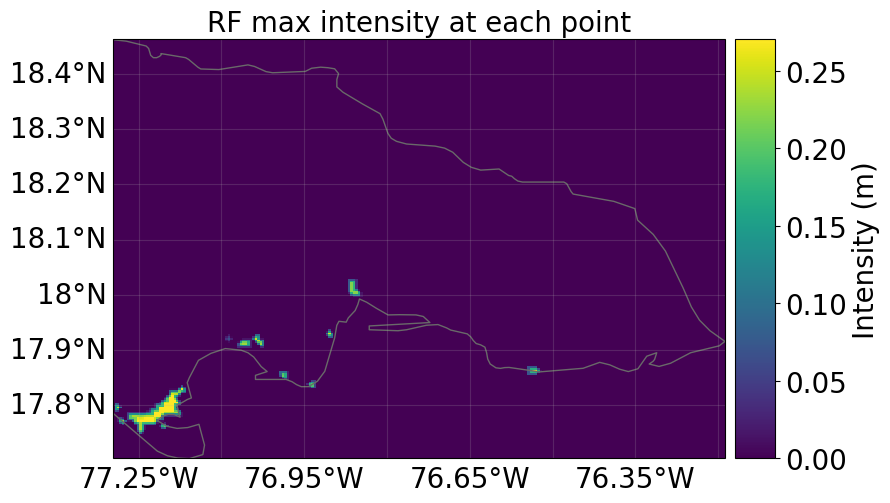

2026-10-05 23:06:52,042 - climada.hazard.io - INFO - Writing /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/hdf5/JAM_inunriver_rcp4p5_2050.hdf5
2026-10-05 23:06:52,056 - climada.hazard.centroids.centr - INFO - Writing /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/hdf5/JAM_inunriver_rcp4p5_2050.hdf5
HDF5 output: /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/hdf5/JAM_inunriver_rcp4p5_2050.hdf5


In [6]:
print("Plotting maximum intensity across events")
hazard.plot_intensity(event=0)
plt.show()
plt.close()

hazard_output_path = HDF5_DIR / OUTPUT_FILENAME
hazard.write_hdf5(hazard_output_path)
print(f"HDF5 output: {hazard_output_path}")


## Run the complete workflow with one call

Instead of the download, construction, and save steps above, do it all in one go:

In [7]:
hazard2 = aqueduct_river.load_aqueduct_river_flood(
    scenario=SCENARIO,
    year=YEAR,
    gcms=GCMS,
    return_periods=RETURN_PERIODS,
    country=COUNTRY,
    bounding_box=BOUNDING_BOX,
    download_dir=DOWNLOAD_DIR,
    output_dir=HDF5_DIR,
    output_filename=OUTPUT_FILENAME,
    force_redownload=FORCE_REDOWNLOAD
)

INFO:climada_toolkit.inputs.hazard.aqueduct_river:Aqueduct file already downloaded: scenario=rcp4p5 year=2050 gcm=GFDL-ESM2M rp=250 url=https://aqueduct.wridata.org/AqueductFloods20/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00250.tif local_path=/Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00250.tif
INFO:climada_toolkit.inputs.hazard.aqueduct_river:Aqueduct file already downloaded: scenario=rcp4p5 year=2050 gcm=MIROC-ESM-CHEM rp=250 url=https://aqueduct.wridata.org/AqueductFloods20/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00250.tif local_path=/Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00250.tif
INFO:climada_toolkit.inputs.hazard.aqueduct_river:Aqueduct file already downloaded: scenario=rcp4p5 year=2050 gcm=GFDL-ESM2M rp=500 url=https://aqueduct.wridata.org/AqueductFloods20/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00500.tif local_path=/Use

2026-10-05 23:06:52,634 - climada.util.coordinates - INFO - Reading /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00500.tif
2026-10-05 23:06:52,677 - climada.util.coordinates - INFO - Reading /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00500.tif
2026-10-05 23:06:52,712 - climada.util.coordinates - INFO - Reading /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00500.tif
2026-10-05 23:06:52,745 - climada.util.coordinates - INFO - Reading /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00250.tif
2026-10-05 23:06:52,780 - climada.util.coordinates - INFO - Reading /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/raw/inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00250

INFO:climada_toolkit.inputs.hazard.aqueduct_river:Created Aqueduct river-flood hazard with 4 events


2026-10-05 23:06:52,815 - climada.hazard.io - INFO - Writing /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/hdf5/JAM_inunriver_rcp4p5_2050.hdf5
2026-10-05 23:06:52,826 - climada.hazard.centroids.centr - INFO - Writing /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/hdf5/JAM_inunriver_rcp4p5_2050.hdf5


INFO:climada_toolkit.inputs.hazard.aqueduct_river:Wrote Aqueduct hazard to /Users/chrisfairless/Projects/climada/climada_python/data/hazard/aqueduct_river/hdf5/JAM_inunriver_rcp4p5_2050.hdf5
